# RNE oscillator long-horizon inspection

This notebook loads the B=100 CRNs that passed the RNE posthoc analysis, sorts them from highest to lowest training loss, and simulates a selected saved `best_network.pkl` over a longer time horizon. By default it selects the highest-loss posthoc-valid network.

In [1]:
from pathlib import Path

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

from RL4CRN.utils.default_tasks.RNEOscillatorTraceTaskKind import (
    RNE_OSCILLATOR_TARGET,
    RNE_OSCILLATOR_TIME,
)

ROOT = Path.cwd()
if ROOT.name == "apps":
    ROOT = ROOT.parent

METHOD = "rl4crn_rne_oscillator_trace_8rxn_stop_risksched085to09_lr1e4_entropy005_s4_c1_rnetol_d256_depth3_p20"
ANALYSIS_CSV = ROOT / "comparisons/rne_oscillator/figures/rne_oscillator_analysis_8rxn_stop_risksched085to09_lr1e4_entropy005_s4_c1_rnetol_d256_depth3_p20_n400.csv"
RAW_ROOT = ROOT / "comparisons/rne_oscillator/data/raw"

# Pick the CRN by rank after sorting posthoc-valid candidates by highest loss first.
# Rank 0 is the highest-loss posthoc-valid CRN.
SELECT_RANK = 0

# Long-horizon simulation controls.
LONG_T_FINAL = 25.0
N_TIMEPOINTS = 5000
INITIAL_CONDITION = np.asarray([1.0, 5.0, 9.0], dtype=float)
LARGE_NUMBER = 1e4

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

## Candidate table

The table below contains only B=100 candidates passing the RNE posthoc analysis. It is sorted by decreasing `best_loss`; change `SELECT_RANK` above to inspect another network.

In [2]:
def seed_label(seed):
    s = str(seed)
    if s.startswith("seed"):
        return s
    return f"seed{int(float(s)):03d}"


candidates = pd.read_csv(ANALYSIS_CSV)
candidates = candidates[candidates["rne_posthoc_success"].fillna(False).astype(bool)].copy()
candidates["seed_label"] = candidates["seed"].map(seed_label)
candidates["network_path"] = candidates["seed_label"].map(lambda s: RAW_ROOT / METHOD / s / "best_network.pkl")
candidates = candidates.sort_values("best_loss", ascending=False).reset_index(drop=True)
candidates.insert(0, "rank", np.arange(len(candidates)))

missing = [str(p) for p in candidates["network_path"] if not Path(p).exists()]
if missing:
    raise FileNotFoundError(f"Missing {len(missing)} best_network.pkl files; first missing: {missing[0]}")

display(candidates[["rank", "seed_label", "best_loss", "success", "stop_reason", "rne_posthoc_success"]].head(25))
print(f"Posthoc-valid B=100 candidates: {len(candidates)}")

,rank,seed_label,best_loss,success,stop_reason,rne_posthoc_success
0,0,seed146,108.722720,False,max_epochs,True
1,1,seed181,92.533601,False,max_epochs,True
2,2,seed059,79.285207,False,max_epochs,True
3,3,seed387,78.246273,False,max_epochs,True
4,4,seed390,76.821340,False,max_epochs,True
5,5,seed076,71.943696,False,max_epochs,True
6,6,seed288,71.412602,False,max_epochs,True
7,7,seed172,70.905002,False,max_epochs,True
8,8,seed127,69.387293,False,max_epochs,True
9,9,seed041,69.276885,False,max_epochs,True


Posthoc-valid B=100 candidates: 126


## Load selected CRN

In [3]:
if not (0 <= SELECT_RANK < len(candidates)):
    raise IndexError(f"SELECT_RANK={SELECT_RANK} outside [0, {len(candidates) - 1}]")

selected = candidates.iloc[SELECT_RANK]
with Path(selected.network_path).open("rb") as f:
    crn = cloudpickle.load(f)

print(f"Selected rank: {int(selected['rank'])}")
print(f"Seed: {selected.seed_label}")
print(f"Best loss: {selected.best_loss:.6g}")
print(f"Network: {selected.network_path}")
print(f"Solver: {crn.solver}, rtol={crn.rtol}, atol={crn.atol}")
print(f"Species: {crn.species_labels}")
print(f"Outputs: {crn.output_labels}")
print(f"Reactions: {crn.num_reactions}")
print(crn)

Selected rank: 0
Seed: seed146
Best loss: 108.723
Network: /local0/rossin/git/GenAI-Net/comparisons/rne_oscillator/data/raw/rl4crn_rne_oscillator_trace_8rxn_stop_risksched085to09_lr1e4_entropy005_s4_c1_rnetol_d256_depth3_p20/seed146/best_network.pkl
Solver: CVODE, rtol=0.001, atol=1e-06
Species: ['X_1', 'X_2', 'X_3']
Outputs: ['X_1', 'X_2', 'X_3']
Reactions: 8
Inputs: [] 
Species: ['X_1', 'X_2', 'X_3'] 
Output Species: ['X_1', 'X_2', 'X_3'] 
X_1 ----> ∅;  [MAK(14.056139945983887)]
X_2 ----> X_1 + X_2;  [MAK(12.394513130187988)]
X_3 ----> X_2 + X_2;  [MAK(9.540204048156738)]
X_3 ----> X_2 + X_3;  [MAK(15.531912803649902)]
X_3 ----> X_3 + X_3;  [MAK(15.516493797302246)]
X_1 + X_2 ----> X_2;  [MAK(3.2487828731536865)]
X_1 + X_3 ----> X_2 + X_2;  [MAK(15.71515941619873)]
X_2 + X_2 ----> X_1 + X_2;  [MAK(0.14825379848480225)]


## Reproduce the original RNE trace window

This short-window simulation uses the same initial condition and time points as notebook 12.

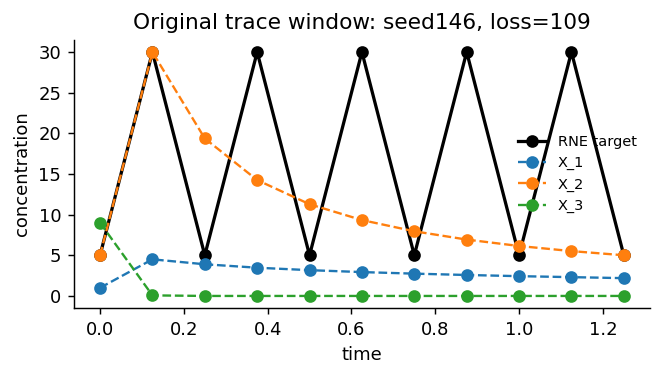

In [ ]:
u_list = [np.asarray([], dtype=np.float32)]
x0_list = [INITIAL_CONDITION]

t_short, x_short_list, y_short_list, _ = crn.transient_response(
    u_list,
    x0_list,
    RNE_OSCILLATOR_TIME.astype(float),
    LARGE_NUMBER=LARGE_NUMBER,
    force=True,
)
x_short = x_short_list[0]

fig, ax = plt.subplots(figsize=(5.2, 3.0))
ax.plot(RNE_OSCILLATOR_TIME, RNE_OSCILLATOR_TARGET, "o-", color="black", lw=1.8, label="RNE target")
for i, label in enumerate(crn.species_labels):
    ax.plot(t_short, x_short[i], "o--", lw=1.3, label=label)
ax.set_xlabel("time")
ax.set_ylabel("concentration")
ax.set_title(f"Original trace window: {selected.seed_label}, loss={selected.best_loss:.3g}")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

## Long-horizon simulation

In [5]:
t_long = np.linspace(0.0, LONG_T_FINAL, N_TIMEPOINTS)
t_long, x_long_list, y_long_list, _ = crn.transient_response(
    u_list,
    x0_list,
    t_long,
    LARGE_NUMBER=LARGE_NUMBER,
    force=True,
)
x_long = x_long_list[0]

finite = np.isfinite(x_long) & (np.abs(x_long) < LARGE_NUMBER)
summary = pd.DataFrame({
    "species": crn.species_labels,
    "min": np.nanmin(np.where(finite, x_long, np.nan), axis=1),
    "max": np.nanmax(np.where(finite, x_long, np.nan), axis=1),
    "final": x_long[:, -1],
    "finite_fraction": finite.mean(axis=1),
})
display(summary)

,species,min,max,final,finite_fraction
0,X_1,2.902846e-01,4.506752,0.431061,1.0
1,X_2,3.547842e-01,33.973525,0.544911,1.0
2,X_3,-6.968722e-07,9.000000,0.000162,1.0


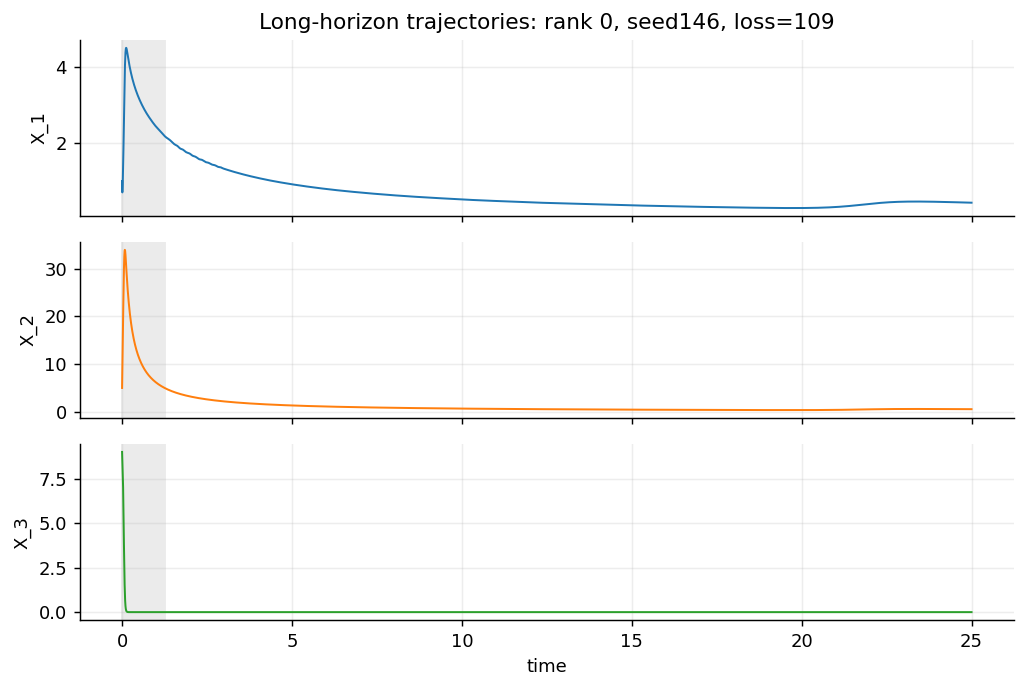

In [6]:
fig, axes = plt.subplots(len(crn.species_labels), 1, figsize=(8.0, 1.8 * len(crn.species_labels)), sharex=True)
axes = np.atleast_1d(axes)

for i, (ax, label) in enumerate(zip(axes, crn.species_labels)):
    ax.plot(t_long, x_long[i], color=f"C{i}", lw=1.1)
    ax.axvspan(RNE_OSCILLATOR_TIME[0], RNE_OSCILLATOR_TIME[-1], color="0.92", zorder=-1)
    ax.set_ylabel(label)
    ax.grid(alpha=0.22)
axes[0].set_title(f"Long-horizon trajectories: rank {SELECT_RANK}, {selected.seed_label}, loss={selected.best_loss:.3g}")
axes[-1].set_xlabel("time")
fig.tight_layout()

## Peak timing and rough period diagnostics

This is only a visual diagnostic, not the RNE posthoc criterion. It helps spot whether the apparent oscillator remains periodic, drifts, damps, or diverges over the longer simulation.

,species,n_peaks,median_period,first_peak_time,last_peak_time,last_peak_value
0,X_1,1,NaN,0.120024,0.120024,4.506752
1,X_2,1,NaN,0.080016,0.080016,33.973525
2,X_3,0,NaN,NaN,NaN,NaN


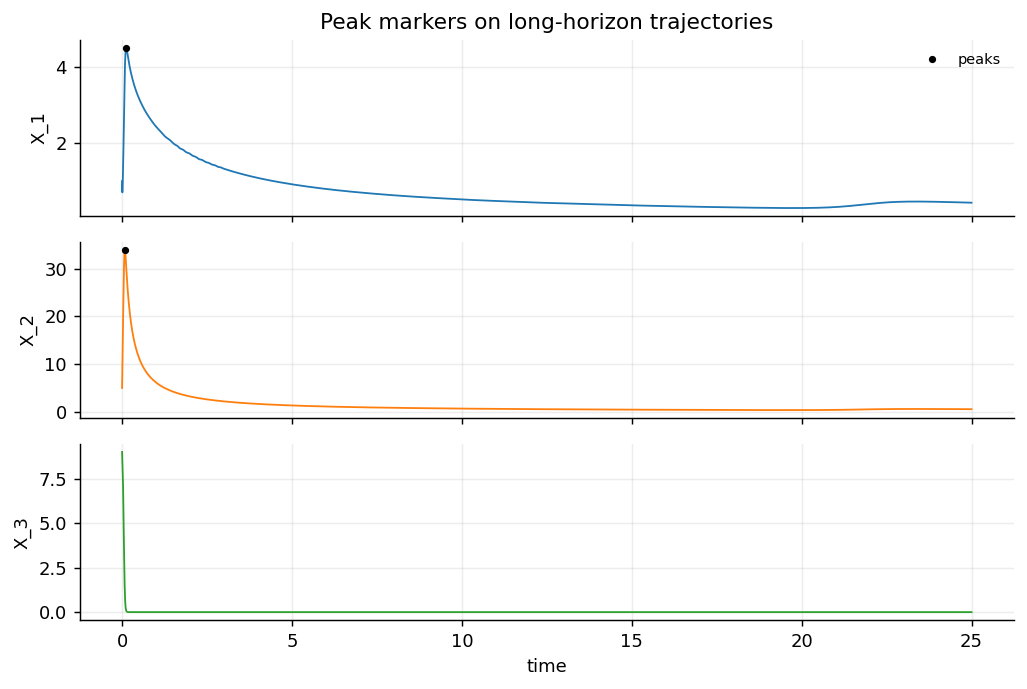

In [7]:
MIN_PEAK_PROMINENCE_FRACTION = 0.05
IGNORE_BEFORE = 0.0

peak_rows = []
fig, axes = plt.subplots(len(crn.species_labels), 1, figsize=(8.0, 1.8 * len(crn.species_labels)), sharex=True)
axes = np.atleast_1d(axes)

for i, (ax, label) in enumerate(zip(axes, crn.species_labels)):
    y = np.asarray(x_long[i], dtype=float)
    mask = np.isfinite(y) & (np.abs(y) < LARGE_NUMBER) & (t_long >= IGNORE_BEFORE)
    yy = y[mask]
    tt = t_long[mask]
    if len(yy) >= 3:
        prom = MIN_PEAK_PROMINENCE_FRACTION * max(float(np.nanmax(yy) - np.nanmin(yy)), 1e-12)
        peaks, props = find_peaks(yy, prominence=prom)
        peak_times = tt[peaks]
        peak_values = yy[peaks]
        periods = np.diff(peak_times)
    else:
        peak_times = np.asarray([])
        peak_values = np.asarray([])
        periods = np.asarray([])

    peak_rows.append({
        "species": label,
        "n_peaks": len(peak_times),
        "median_period": np.nan if len(periods) == 0 else float(np.median(periods)),
        "first_peak_time": np.nan if len(peak_times) == 0 else float(peak_times[0]),
        "last_peak_time": np.nan if len(peak_times) == 0 else float(peak_times[-1]),
        "last_peak_value": np.nan if len(peak_values) == 0 else float(peak_values[-1]),
    })

    ax.plot(t_long, y, color=f"C{i}", lw=1.0)
    ax.plot(peak_times, peak_values, "o", color="black", ms=3.0, label="peaks")
    ax.set_ylabel(label)
    ax.grid(alpha=0.22)
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
axes[0].set_title("Peak markers on long-horizon trajectories")
axes[-1].set_xlabel("time")
fig.tight_layout()

display(pd.DataFrame(peak_rows))